In [404]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE,r2_score as R2

# Simple Linear Regression (1 independent variable + 1 target variable)

## Experiment with Original Data

### Load Data

In [405]:
# load package for loading data
df = pd.read_csv('boston_housing.csv')
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [406]:
housing_dataset = df
housing_dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Train-Test Set Spliting

Requirement:
* Use the average number of rooms (RM) to estimate the house price (MEDV)
* Split training, testing set with ratio 7:3 and random state = 42

In [407]:
X = df[['RM']]
y = df['MEDV']

In [408]:
# load package for spliting data


In [409]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Data Visualization

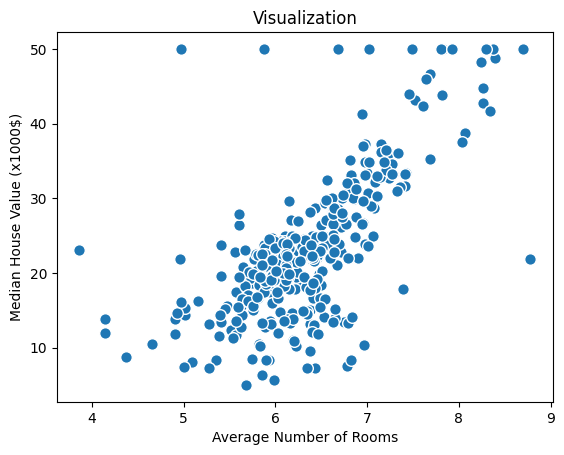

In [410]:
# visualize data
# xlabel: 'Average Number of Rooms'; ylabel: 'Median House Value (x1000$)'
plt.scatter(X_train, y_train, facecolor='tab:blue', edgecolor='white', s=70)
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (x1000$)')
plt.title('Visualization')
plt.show()

### Linear Regression (Base)

In [411]:
class LinearRegressBase:
    def __init__(self, learning_rate=1e-3, max_iter=200, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.w = None  # weights (vector)
        self.b = None  # bias (scalar)
        self.costs = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X)
        y = np.array(y)

        # Trường hợp 1 biến độc lập
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        m, n = X.shape  # m: số mẫu, n: số đặc trưng

        # Khởi tạo trọng số và bias ngẫu nhiên
        self.w = np.random.randn(n)
        self.b = np.random.randn()

        # Gradient Descent
        for i in range(self.max_iter):
            y_pred = np.dot(X, self.w) + self.b

            # Tính gradient
            dw = (-2/m) * np.dot(X.T, (y - y_pred))
            db = (-2/m) * np.sum(y - y_pred)

            # Cập nhật trọng số
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Lưu lại hàm lỗi (cost)
            cost = np.mean((y - y_pred)**2)
            self.costs.append(cost)

        return self

    def predict(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.w) + self.b


### Gradient Descent

In [412]:
class GradientDescentRegressor:
    def __init__(self, learning_rate=0.001, max_iter=200, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.w = None
        self.b = None
        self.costs = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X).flatten()
        y = np.array(y)
        m = len(y)

        self.w = np.random.randn()
        self.b = np.random.randn()

        for i in range(self.max_iter):
            y_pred = self.w * X + self.b
            dw = (-2/m) * np.sum(X * (y - y_pred))
            db = (-2/m) * np.sum(y - y_pred)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            cost = np.mean((y - y_pred)**2)
            self.costs.append(cost)

        return self

    def predict(self, X):
        return self.w * np.array(X).flatten() + self.b


- Requirement: Experiment with
-- Different learning rate values: eta = {1e-2, 1e-3, 1e-4}
-- Maximum number of iterations = 200
-- Random state = 42
- What is the suitable 'learning rate' value?

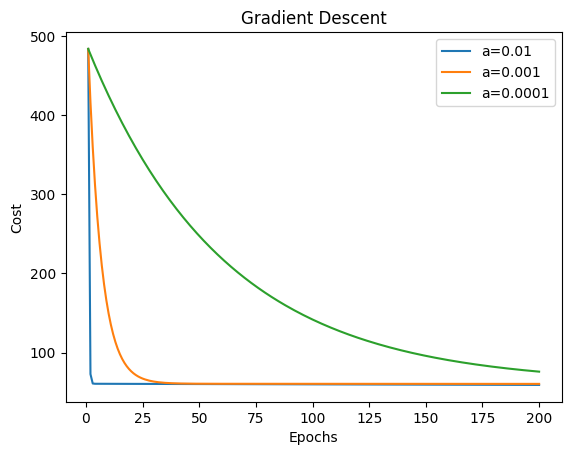

In [413]:
# Initialize the model

reg_GD = GradientDescentRegressor(learning_rate=1e-3, max_iter=200, random_state=42)
#qua so do tren ta co the thay
#1e-2 -> nhanh , co the over shoot
#1e-4 -> qua cham, nhung an toan
# on dinh nhat 1e-3


# Train model
reg_GD.fit(X_train, y_train)

learning_rates = [1e-2, 1e-3, 1e-4]
# Visualize the cost trend
for eta in learning_rates:
    reg = GradientDescentRegressor(learning_rate=eta, max_iter=200, random_state=42)
    reg.fit(X_train, y_train)
    plt.plot(range(1, len(reg.costs)+1), reg.costs, label=f'a={eta}')

plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Gradient Descent')
plt.legend()
plt.show()

Visualize the prediction of Gradient Descent model on Training Data

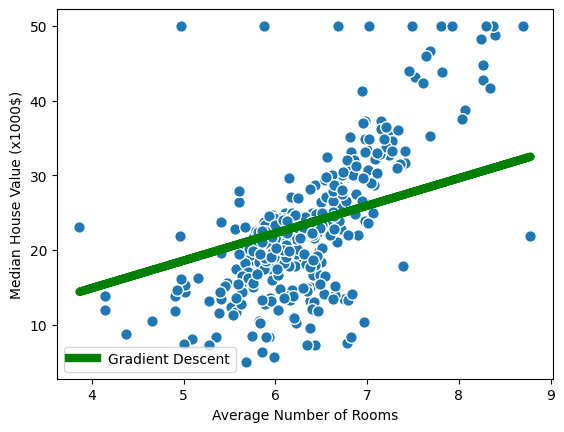

In [414]:
plt.scatter(X_train, y_train, facecolor='tab:blue', edgecolor='white', s=70)
plt.plot(X_train, reg_GD.predict(X_train), color='green', lw=6, label='Gradient Descent')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Stochastic Gradient Descent

In [415]:
class StochasticGradientDescent:
    def __init__(self, learning_rate=0.001, max_iter=200, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.w = None  # weights (vector)
        self.b = None  # bias (scalar)
        self.costs = []  # lưu loss trung bình mỗi epoch

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X)
        y = np.array(y)

        # reshape nếu chỉ 1 biến
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        m, n = X.shape
        self.w = np.random.randn(n)
        self.b = np.random.randn()

        for epoch in range(self.max_iter):
            indices = np.arange(m)
            np.random.shuffle(indices)  # shuffle dữ liệu mỗi epoch

            cost_epoch = 0
            for i in indices:
                xi = X[i]
                yi = y[i]

                # dự đoán
                y_pred = np.dot(xi, self.w) + self.b

                # gradient
                dw = -2 * xi * (yi - y_pred)
                db = -2 * (yi - y_pred)

                # cập nhật weights
                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

                cost_epoch += (yi - y_pred)**2

            # lưu cost trung bình mỗi epoch
            self.costs.append(cost_epoch / m)

        return self

    def predict(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.w) + self.b

- Requirement: Experiment with
-- Different learning rate values: eta0 = 1e-4
-- Maximum number of iterations = 200
-- Random state = 42

In [416]:
# Initialize the model
reg_SGD = StochasticGradientDescent(learning_rate=1e-4, max_iter=200, random_state=42)

# Train model
reg_SGD.fit(X_train, y_train)

Visualize the prediction of Stochastic Gradient Descent model on Training Data

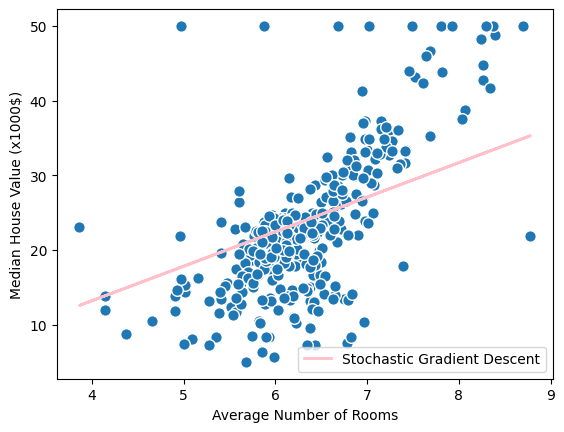

In [417]:
plt.scatter(X_train, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train, reg_SGD.predict(X_train), color='pink', lw=2, label='Stochastic Gradient Descent')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Normal Equation (sklearn)

In [418]:
# Intialize the Normal Equation model
reg_NE = LinearRegression()

# Train model
reg_NE.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Visualize the prediction of Normal Equation model on Training Data

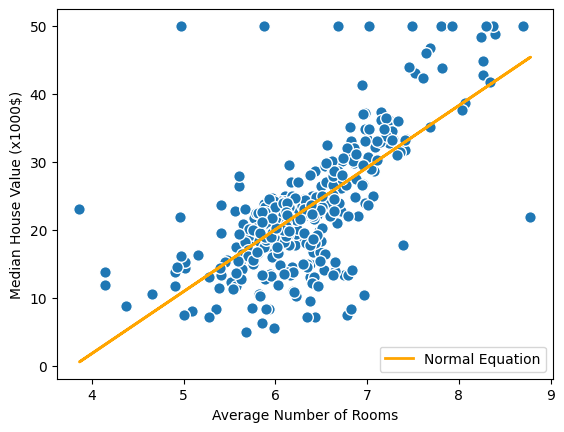

In [419]:
plt.scatter(X_train, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train, reg_NE.predict(X_train), color='orange', lw=2, label='Normal Equation')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Visualize all models on Training Data

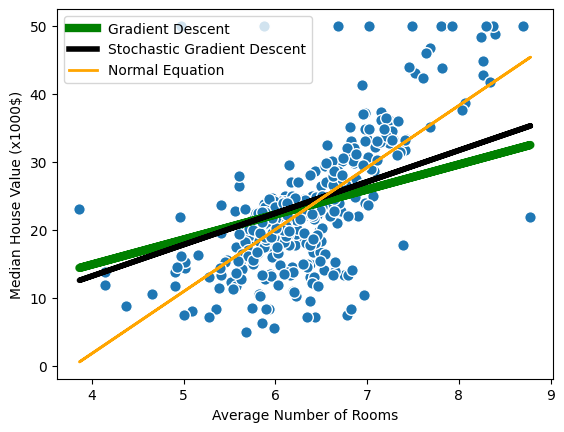

In [420]:
plt.scatter(X_train, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train, reg_GD.predict(X_train), color='green', lw=6, label='Gradient Descent')
plt.plot(X_train, reg_SGD.predict(X_train), color='black', lw=4, label='Stochastic Gradient Descent')
plt.plot(X_train, reg_NE.predict(X_train), color='orange', lw=2, label='Normal Equation')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Algorithms Comparisons

Weight Comparisions

In [421]:
w_GD = reg_GD.w
w_SGD = reg_SGD.w
w_NE = reg_NE.coef_
print(w_GD)
print(w_SGD)
print(w_NE)

3.678352985345743
[4.62271782]
[9.1181022]


Performance Comparisons (on Testing Set)

In [422]:
y_pred_GD = reg_GD.predict(X_test)

In [423]:
y_pred_SGD = reg_SGD.predict(X_test)

In [424]:
y_pred_NE = reg_NE.predict(X_test)

In [425]:
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score as R2

In [426]:
print('MAE of GD:', round(MAE(y_test, y_pred_GD), 6))
print('MAE of SGD:', round(MAE(y_test, y_pred_SGD), 6))
print('MAE of NE:', round(MAE(y_test, y_pred_NE), 6))

MAE of GD: 5.401707
MAE of SGD: 5.342325
MAE of NE: 4.314224


In [427]:
print('MSE of GD:', round(MSE(y_test, y_pred_GD), 6))
print('MSE of SGD:', round(MSE(y_test, y_pred_SGD), 6))
print('MSE of NE:', round(MSE(y_test, y_pred_NE), 6))

MSE of GD: 54.524888
MSE of SGD: 51.92648
MSE of NE: 40.35145


In [428]:
print('R2 of GD:', round(R2(y_test, y_pred_GD), 6))
print('R2 of SGD:', round(R2(y_test, y_pred_SGD), 6))
print('R2 of NE:', round(R2(y_test, y_pred_NE), 6))

R2 of GD: 0.268251
R2 of SGD: 0.303123
R2 of NE: 0.458465


## Experiment with Standardized Data

In [429]:
# Re-load the dataset
housing_dataset = df.copy()

In [430]:
# load the package for standardizing data (Standard Scaler)


In [431]:
# Standardize the 'RM' column
scaler = StandardScaler()
housing_dataset[['RM']] = scaler.fit_transform(housing_dataset[['RM']])

In [432]:
# X_new <- 'RM' column, y <- 'MEDV' column
X_new = housing_dataset[['RM']]
y = housing_dataset['MEDV']

In [433]:
# Train-test spliting (7:3, random state = 42)
X_train_norm, X_test_norm, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

### Gradient Descent

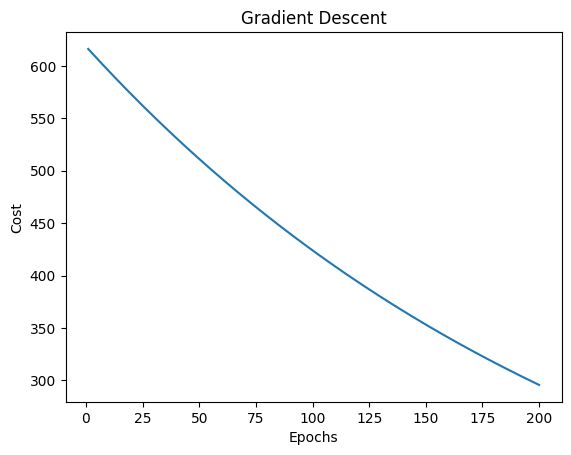

In [434]:
# Initalize the Gradient Descent model with: learning rate = 1e-3, max_iter = 200, random_state = 42
reg_GD = GradientDescentRegressor(learning_rate=1e-3, max_iter=200, random_state=42)

# Train model on standardized data
reg_GD.fit(X_train_norm, y_train)


# Visualize the cost trend
plt.plot(range(1, len(reg_GD.costs) + 1), reg_GD.costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Gradient Descent')
plt.show()

Visualize the prediction of Gradient Descent model on Training Data



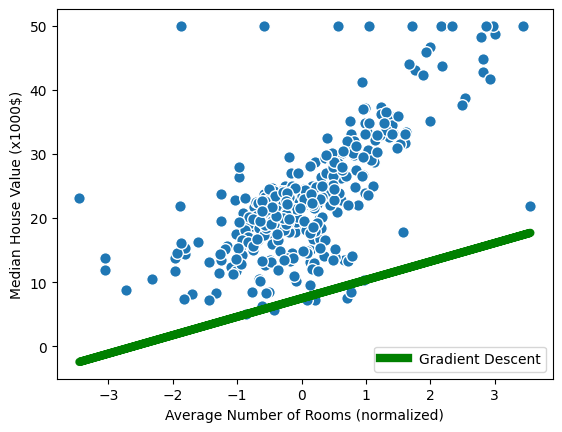

In [435]:
plt.scatter(X_train_norm, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train_norm, reg_GD.predict(X_train_norm), color='green', lw=6, label='Gradient Descent')
plt.xlabel('Average Number of Rooms (normalized)')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Stochastic Gradient Descent

In [436]:
# Initalize the Stochastic Gradient Descent model with: eta0 = 1e-3, max_iter = 200, random_state=42, learning_rate = 'constant'
reg_SGD = SGDRegressor(eta0=1e-3, max_iter=200, random_state=42, learning_rate='constant')

# Train SGD model on standardized data
reg_SGD.fit(X_train_norm, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,200
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


Visualize the prediction of Stochastic Gradient Descent model on Training Data


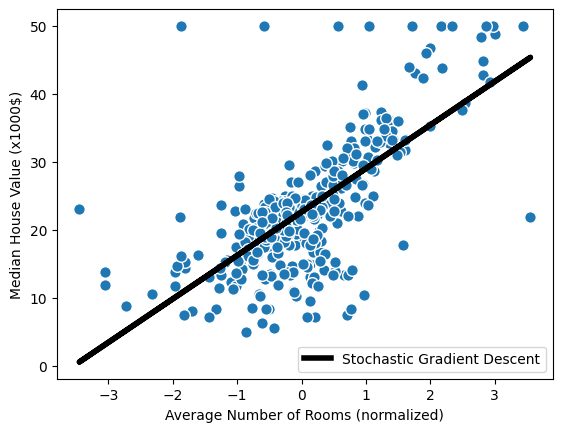

In [437]:
plt.scatter(X_train_norm, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train_norm, reg_SGD.predict(X_train_norm), color='black', lw=4, label='Stochastic Gradient Descent')
plt.xlabel('Average Number of Rooms (normalized)')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Normal Equation (sklearn)

In [438]:
# Initalize the Normal Equation model
reg_NE = LinearRegression()

# Train model
reg_NE.fit(X_train_norm, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


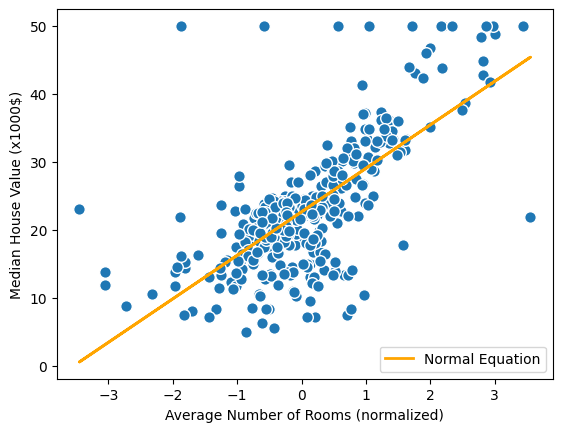

In [439]:
plt.scatter(X_train_norm, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train_norm, reg_NE.predict(X_train_norm), color='orange', lw=2, label='Normal Equation')
plt.xlabel('Average Number of Rooms (normalized)')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Visualize all models on Training Data

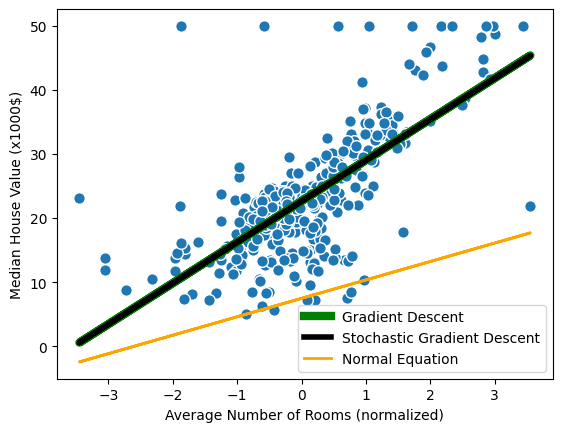

In [440]:
plt.scatter(X_train_norm, y_train, c='tab:blue', edgecolor='white', s=70)
plt.plot(X_train_norm, reg_NE.predict(X_train_norm), color='green', lw=6, label='Gradient Descent')
plt.plot(X_train_norm, reg_SGD.predict(X_train_norm), color='black', lw=4, label='Stochastic Gradient Descent')
plt.plot(X_train_norm, reg_GD.predict(X_train_norm), color='orange', lw=2, label='Normal Equation')
plt.xlabel('Average Number of Rooms (normalized)')
plt.ylabel('Median House Value (x1000$)')
plt.legend()
plt.show()

### Algorithms Comparisons

In [441]:
w_GD = reg_GD.w
w_GD

np.float64(2.876616107179754)

In [442]:
w_SGD = reg_SGD.coef_
w_SGD

array([6.39567675])

In [443]:
w_NE = reg_NE.coef_
w_NE

array([6.40020122])

In [444]:
y_pred_GD = reg_GD.predict(X_test_norm)

In [445]:
y_pred_SGD = reg_SGD.predict(X_test_norm)

In [446]:
y_pred_NE = reg_NE.predict(X_test_norm)

In [447]:
print('MAE of GD:', round(MAE(y_test, y_pred_GD), 6))
print('MAE of SGD:', round(MAE(y_test, y_pred_SGD), 6))
print('MAE of NE:', round(MAE(y_test, y_pred_NE), 6))

MAE of GD: 14.334021
MAE of SGD: 4.312817
MAE of NE: 4.314224


In [448]:
print('MSE of GD:', round(MSE(y_test, y_pred_GD), 6))
print('MSE of SGD:', round(MSE(y_test, y_pred_SGD), 6))
print('MSE of NE:', round(MSE(y_test, y_pred_NE), 6))

MSE of GD: 255.803841
MSE of SGD: 40.336472
MSE of NE: 40.35145


In [449]:
print('R2 of GD:', round(R2(y_test, y_pred_GD), 6))
print('R2 of SGD:', round(R2(y_test, y_pred_SGD), 6))
print('R2 of NE:', round(R2(y_test, y_pred_NE), 6))

R2 of GD: -2.433005
R2 of SGD: 0.458666
R2 of NE: 0.458465


# Multiple Linear Regression (n independent variable (n >=2) + 1 target variable)

## Experiment with normal data

In [450]:
# Re-load dataset
housing_dataset = df.copy()

* X: 13 remaining variables (except 'MEDV' variable)
* y: 'MEDV' variable

In [451]:
X=housing_dataset.drop(columns=['MEDV']).values
y=housing_dataset['MEDV'].values.reshape(-1,1)

In [452]:
# Train-test set spliting with ratio 7:3, random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Gradient Descent

- Experiment with:
-- max_iter = 200
-- random_state = 42
-- learning_rate (eta) = {1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8}
- What is the suitable learning rate value?

In [453]:

class LinearRegressionGD:
    def __init__(self, lr=0.01, max_iter=20, random_state=42):
        self.lr=lr
        self.max_iter=max_iter
        self.w=None
        self.random_state=random_state
        self.costs=[]
    def add_bias(self,X_train):
        N=X_train.shape[0]
        X_bar = np.concatenate((np.ones((N, 1)), X_train), axis=1)
        return X_bar
    def predict(self, X_train):
        X_bar=self.add_bias(X_train)
        return X_bar @ self.w
    def fit(self, X_train, y_train):
        rgen = np.random.RandomState(self.random_state)
        self.w = rgen.normal(loc=0.0, scale=0.01, size=(X_train.shape[1] + 1, 1))

        N=X_train.shape[0]
        X_bar=self.add_bias(X_train)
        for _ in range (self.max_iter):
            L = (1/N) * X_bar.T @ (X_bar@self.w-y_train)
            self.w = self.w - (self.lr * L)
            diff=self.predict(X_train)-y_train
            self.costs.append((1/(2*N)) * np.sum(diff**2))

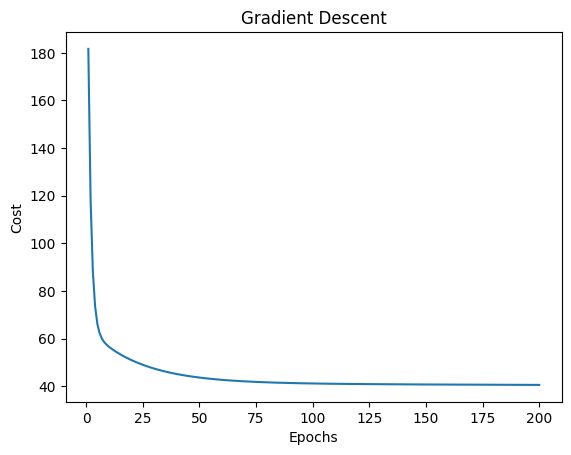

In [454]:
# Initalize the GD model
reg_GD = LinearRegressionGD(max_iter=200,lr=1e-6)

# Train model
reg_GD.fit(X_train, y_train)

# Visualize the cost trend
plt.plot(range(1, len(reg_GD.costs) + 1), reg_GD.costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Gradient Descent')
plt.show()

### Stochastic Gradient Descent

In [455]:

class Gradient_Decent_Stochastic:
    def __init__(self, eta0=1e-4, max_iter=200 ,random_state=42):
        self.eta0=eta0
        self.max_iter=max_iter
        self.w=None
        self.random_state=random_state
        self.costs=[]
    def add_bias(self,X_train):
        N=X_train.shape[0]
        X_bar = np.concatenate((np.ones((N, 1)), X_train), axis=1)
        return X_bar
    def predict(self, X_train):
        X_bar=self.add_bias(X_train)
        return X_bar @ self.w
    def fit(self, X_train, y_train):
        rgen = np.random.RandomState(self.random_state)
        self.w = rgen.normal(loc=0.0, scale=0.01, size=(X_train.shape[1] + 1, 1))

        N=X_train.shape[0]
        X_bar=self.add_bias(X_train)
        for epoch in range (self.max_iter):
            cost=0
            indices = np.arange(N)
            np.random.shuffle(indices)
            for i in indices:
                x_i = X_bar[i, :].reshape(1, -1)
                y_i = y_train[i, :].reshape(1, -1)
                y_pred = x_i @ self.w
                error = y_pred - y_i

                self.w -= self.eta0 * x_i.T @ error

                cost += (error ** 2).sum() / (2 * N)

            self.costs.append(cost)

In [456]:
# Initialize the SGD model
reg_SGD = Gradient_Decent_Stochastic(max_iter=200, eta0=1e-6)

# Train model
reg_SGD.fit(X_train, y_train)

### Normal Equation

In [457]:
# Add the '1' column to data


In [458]:
# Intialize the NE model
reg_NE = LinearRegression()

# Train model
reg_NE.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Algorithms Comparisons

In [459]:
w_GD = reg_GD.w
w_GD

array([[ 0.00520607],
       [-0.0045773 ],
       [ 0.01952586],
       [ 0.0135655 ],
       [-0.00223354],
       [-0.00226858],
       [ 0.01816915],
       [ 0.01053657],
       [-0.00325487],
       [ 0.00391707],
       [-0.00248276],
       [-0.00208118],
       [ 0.06254859],
       [-0.02423133]])

In [460]:
w_SGD = reg_SGD.w
w_SGD

array([[ 0.03938432],
       [-0.16316532],
       [ 0.10186957],
       [-0.06392749],
       [ 0.02448113],
       [ 0.01108322],
       [ 0.41028924],
       [ 0.10960695],
       [ 0.04437359],
       [ 0.00427278],
       [ 0.01379249],
       [ 0.23459669],
       [ 0.0326587 ],
       [-0.74494267]])

In [461]:
w_NE = reg_NE.coef_
w_NE

array([[-1.33470103e-01,  3.58089136e-02,  4.95226452e-02,
         3.11983512e+00, -1.54170609e+01,  4.05719923e+00,
        -1.08208352e-02, -1.38599824e+00,  2.42727340e-01,
        -8.70223437e-03, -9.10685208e-01,  1.17941159e-02,
        -5.47113313e-01]])

In [462]:
y_pred_GD = reg_GD.predict(X_test)

In [463]:
y_pred_SGD = reg_SGD.predict(X_test)

In [464]:
y_pred_NE = reg_NE.predict(X_test)

In [465]:
print('MAE of GD:', round(MAE(y_test, y_pred_GD), 6))
print('MAE of SGD:', round(MAE(y_test, y_pred_SGD), 6))
print('MAE of NE:', round(MAE(y_test, y_pred_NE), 6))

MAE of GD: 6.522154
MAE of SGD: 5.460041
MAE of NE: 3.16271


In [466]:
print('MSE of GD:', round(MSE(y_test, y_pred_GD), 6))
print('MSE of SGD:', round(MSE(y_test, y_pred_SGD), 6))
print('MSE of NE:', round(MSE(y_test, y_pred_NE), 6))

MSE of GD: 73.058508
MSE of SGD: 49.047205
MSE of NE: 21.517444


In [467]:
print('R2 of GD:', round(R2(y_test, y_pred_GD), 6))
print('R2 of SGD:', round(R2(y_test, y_pred_SGD), 6))
print('R2 of NE:', round(R2(y_test, y_pred_NE), 6))

R2 of GD: 0.019521
R2 of SGD: 0.341764
R2 of NE: 0.711226


## Experiment with Standardized Data

In [468]:
# Re-load dataset
housing_dataset = df.copy()

In [469]:
# Get the columns' names
name_columns = housing_dataset.columns.values
name_columns

array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'], dtype=object)

In [470]:
# Initialize the standardize scaler
scaler = StandardScaler()

# Standardize all independent variables
housing_dataset[name_columns[:-1]] = scaler.fit_transform(housing_dataset[name_columns[:-1]])

X_new <- 13 independent variables

y <- 'MEDV' column

In [471]:
X_new=housing_dataset.drop(columns=['MEDV']).values
y=housing_dataset['MEDV'].values.reshape(-1,1)

In [472]:
# Split train-test set (7:3, random_state = 42)
X_train_norm, X_test_norm, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

### Gradient Descent

- Experiment with following learning rates = {1e-3, 1e-5, 1e-4}
- max_iter = 200
- random_state = 42

In [473]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, max_iter=20, random_state=42):
        self.lr=lr
        self.max_iter=max_iter
        self.w=None
        self.random_state=random_state
        self.costs=[]
    def add_bias(self,X_train):
        N=X_train.shape[0]
        X_bar = np.concatenate((np.ones((N, 1)), X_train), axis=1)
        return X_bar
    def predict(self, X_train):
        X_bar=self.add_bias(X_train)
        return X_bar @ self.w
    def fit(self, X_train, y_train):
        rgen = np.random.RandomState(self.random_state)
        self.w = rgen.normal(loc=0.0, scale=0.01, size=(X_train.shape[1] + 1, 1))

        N=X_train.shape[0]
        X_bar=self.add_bias(X_train)
        for _ in range (self.max_iter):
            L = (1/N) * X_bar.T @ (X_bar@self.w-y_train)
            self.w = self.w - (self.lr * L)
            diff=self.predict(X_train)-y_train
            self.costs.append((1/(2*N)) * np.sum(diff**2))

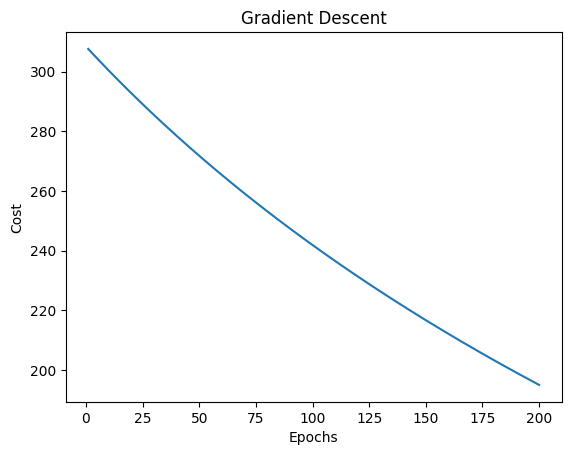

In [474]:
# Initalize the GD model
reg_GD = LinearRegressionGD(lr=1e-3,max_iter=200)

# Train model on normalized data
reg_GD.fit(X_train_norm, y_train)

# Visualize the cost trend
plt.plot(range(1, len(reg_GD.costs) + 1), reg_GD.costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Gradient Descent')
plt.show()

### Stochastic Gradient Descent

In [475]:
# Initialize SGD model (eta0=1e-4, max_iter=200, random_state=42, learning_rate='constant')
reg_SGD = Gradient_Decent_Stochastic(max_iter=200, eta0=1e-4)

# Train model
reg_SGD.fit(X_train_norm, y_train)

### Normal Equation (sklearn)

In [476]:
# Initialize NE model
reg_NE = LinearRegression()
# Train model
reg_NE.fit(X_train_norm, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Algorithms Comparisons

In [477]:
w_GD = reg_GD.w
w_GD

array([[ 4.15560107],
       [-0.4607396 ],
       [ 0.31848834],
       [-0.44309657],
       [ 0.42484686],
       [-0.30259891],
       [ 1.22779046],
       [-0.27786609],
       [ 0.06026499],
       [-0.38228445],
       [-0.46571197],
       [-0.95816345],
       [ 0.48960457],
       [-1.10804136]])

In [478]:
w_SGD = reg_SGD.w
w_SGD

array([[22.47515095],
       [-0.946116  ],
       [ 0.40296546],
       [-0.05090664],
       [ 0.86456773],
       [-1.1079046 ],
       [ 3.09121355],
       [-0.39194907],
       [-2.23063478],
       [ 0.88334548],
       [-0.32059617],
       [-1.86642434],
       [ 1.09817408],
       [-3.78815808]])

In [479]:
w_NE = np.append(reg_NE.intercept_, reg_NE.coef_)
w_NE

array([22.50945471, -1.14691411,  0.83432605,  0.33940694,  0.79163612,
       -1.784727  ,  2.84783949, -0.30429306, -2.91562521,  2.11140045,
       -1.46519951, -1.9696347 ,  1.07567771, -3.90310727])

In [480]:
y_pred_GD = reg_GD.predict(X_test_norm)

In [481]:
y_pred_SGD = reg_SGD.predict(X_test_norm)

In [482]:
y_pred_NE = reg_NE.predict(X_test_norm)

In [483]:
print('MAE of GD:', round(MAE(y_test, y_pred_GD), 6))
print('MAE of SGD:', round(MAE(y_test, y_pred_SGD), 6))
print('MAE of NE:', round(MAE(y_test, y_pred_NE), 6))

MAE of GD: 17.757272
MAE of SGD: 3.206068
MAE of NE: 3.16271


In [484]:
print('MSE of GD:', round(MSE(y_test, y_pred_GD), 6))
print('MSE of SGD:', round(MSE(y_test, y_pred_SGD), 6))
print('MSE of NE:', round(MSE(y_test, y_pred_NE), 6))

MSE of GD: 350.471332
MSE of SGD: 22.909606
MSE of NE: 21.517444


In [485]:
print('R2 of GD:', round(R2(y_test, y_pred_GD), 6))
print('R2 of SGD:', round(R2(y_test, y_pred_SGD), 6))
print('R2 of NE:', round(R2(y_test, y_pred_NE), 6))

R2 of GD: -3.703486
R2 of SGD: 0.692543
R2 of NE: 0.711226


# Explain what $R^2$ coefficient is.

In [486]:
'''

R² là chỉ số dùng để đo lường mức độ mà mô hình hồi quy giải thích được sự biến thiên của biến mục tiêu.  
Nó cho biết mức độ mà giá trị dự đoán gần với giá trị thực tế.

**Công thức:**
R² = 1 - [Σ(yᵢ - ŷᵢ)² / Σ(yᵢ - ȳ)²]

Trong đó:  
- yᵢ: giá trị thực tế  
- ŷᵢ: giá trị dự đoán  
- ȳ: giá trị trung bình của y

Diễn giải:
- R² = 1 → mô hình dự đoán hoàn hảo (không có sai số)  
- R² = 0 → mô hình không giải thích được sự biến thiên (như dự đoán bằng trung bình)  
- R² < 0 → mô hình tệ hơn cả việc luôn dự đoán bằng trung bình

**Kết luận:**  
R² cho biết mô hình giải thích được bao nhiêu phần trăm sự biến thiên của biến phụ thuộc.  
Giá trị R² càng gần 1 thì mô hình càng phù hợp với dữ liệu.
'''

'\n\nR² là chỉ số dùng để đo lường mức độ mà mô hình hồi quy giải thích được sự biến thiên của biến mục tiêu.  \nNó cho biết mức độ mà giá trị dự đoán gần với giá trị thực tế.\n\n**Công thức:**\nR² = 1 - [Σ(yᵢ - ŷᵢ)² / Σ(yᵢ - ȳ)²]\n\nTrong đó:  \n- yᵢ: giá trị thực tế  \n- ŷᵢ: giá trị dự đoán  \n- ȳ: giá trị trung bình của y\n\nDiễn giải:\n- R² = 1 → mô hình dự đoán hoàn hảo (không có sai số)  \n- R² = 0 → mô hình không giải thích được sự biến thiên (như dự đoán bằng trung bình)  \n- R² < 0 → mô hình tệ hơn cả việc luôn dự đoán bằng trung bình\n\n**Kết luận:**  \nR² cho biết mô hình giải thích được bao nhiêu phần trăm sự biến thiên của biến phụ thuộc.  \nGiá trị R² càng gần 1 thì mô hình càng phù hợp với dữ liệu.\n'